# Introduction

Today we'll dive deep into a dataset all about LEGO. From the dataset we can ask whole bunch of interesting questions about the history of the LEGO company, their product offering, and which LEGO set ultimately rules them all:

<ul type="square">
<li>What is the most enormous LEGO set ever created and how many parts did it have?</li>

<li>How did the LEGO company start out? In which year were the first LEGO sets released and how many sets did the company sell when it first launched?</li>

<li>Which LEGO theme has the most sets? Is it one of LEGO's own themes like Ninjago or a theme they licensed liked Harry Potter or Marvel Superheroes?</li>

<li>When did the LEGO company really expand its product offering? Can we spot a change in the company strategy based on how many themes and sets did it released year-on-year?</li>

<li>Did LEGO sets grow in size and complexity over time? Do older LEGO 
sets tend to have more or fewer parts than newer sets?</li>
</ul>

**Data Source**

[Rebrickable](https://rebrickable.com/downloads/) has compiled data on all the LEGO pieces in existence. I recommend you use download the .csv files provided in this lesson. 

# Import Statements

In [2]:
import pandas as pd

# Data Exploration

**Challenge**: How many different colours does the LEGO company produce? Read the colors.csv file in the data folder and find the total number of unique colours. Try using the [.nunique() method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html?highlight=nunique#pandas.DataFrame.nunique) to accomplish this.

In [3]:
df_colors = pd.read_csv("data/colors.csv")

In [4]:
df_colors.name.nunique()

135

In [5]:
df_colors.head()

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


**Challenge**: Find the number of transparent colours where <code>is_trans == 't'</code> versus the number of opaque colours where <code>is_trans == 'f'</code>. See if you can accomplish this in two different ways.

In [6]:
df_colors.groupby("is_trans").count()

,id,name,rgb
is_trans,,,
f,107,107,107
t,28,28,28


### Understanding LEGO Themes vs. LEGO Sets

Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.

<img src="assets/lego_themes.png">

A lego set is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.


<img src="assets/lego_sets.png">

The <code>sets.csv</code> data contains a list of sets over the years and the number of parts that each of these sets contained.

**Challenge**: Read the sets.csv data and take a look at the first and last couple of rows. 

In [7]:
df_sets=pd.read_csv("data/sets.csv")

In [8]:
df_sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [9]:
df_sets.tail(10)

,set_num,name,year,theme_id,num_parts
15700,WEETABIX5-1,Weetabix Promotional Lego Village,1976,413,0
15701,WHITEHOUSE-1,Micro White House,2015,598,59
15702,Wiesbaden-1,"LEGO Store Grand Opening Exclusive Set, Wiesba...",2010,408,146
15703,WILLIAM-1,Will.i.am,2016,535,3
15704,WISHINGWELL-1,Wishing Well,2013,494,28
15705,wwgp1-1,Wild West Limited Edition Gift Pack,1996,476,0
15706,XMASTREE-1,Christmas Tree,2019,410,26
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52
15709,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413


**Challenge**: In which year were the first LEGO sets released and what were these sets called?

In [10]:
df_sets.sort_values('year', ascending=True)

,set_num,name,year,theme_id,num_parts
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9534,700.2-1,Large Gift Set (ABB),1949,365,178
...,...,...,...,...,...
5399,41919-1,Power Bracelet,2020,688,33
8217,60265-1,Ocean Exploration Base,2020,52,495
11335,75547-1,Minion Pilot in Training,2021,689,0
11337,75550-1,Minions Kung Fu Battle,2021,689,0


**Challenge**: How many different sets did LEGO sell in their first year? How many types of LEGO products were on offer in the year the company started?

In [11]:
df_sets.query("year == 1949").count()

set_num      5
name         5
year         5
theme_id     5
num_parts    5
dtype: int64

**Challenge**: Find the top 5 LEGO sets with the most number of parts. 

In [12]:
df_sets.sort_values("num_parts", ascending=False).head()

,set_num,name,year,theme_id,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987
11183,75192-1,UCS Millennium Falcon,2017,171,7541
10551,71043-1,Hogwarts Castle,2018,246,6020
295,10256-1,Taj Mahal,2017,673,5923
221,10189-1,Taj Mahal,2008,673,5922


**Challenge**: Use <code>.groupby()</code> and <code>.count()</code> to show the number of LEGO sets released year-on-year. How do the number of sets released in 1955 compare to the number of sets released in 2019? 

In [13]:
df_sets.groupby("year").count().query("year == 1955 | year == 2019")

,set_num,name,theme_id,num_parts
year,,,,
1955,28,28,28,28
2019,840,840,840,840


In [14]:
type(df_sets.groupby("year").count())

pandas.DataFrame

**Challenge**: Show the number of LEGO releases on a line chart using Matplotlib. <br>
<br>
Note that the .csv file is from late 2020, so to plot the full calendar years, you will have to exclude some data from your chart. Can you use the slicing techniques covered in Day 21 to avoid plotting the last two years? The same syntax will work on Pandas DataFrames. 

In [15]:
df_sets_per_full_year = df_sets.groupby("year").count()[:-2:]

C:\Users\pedan\AppData\Local\Temp\ipykernel_14204\2468524340.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


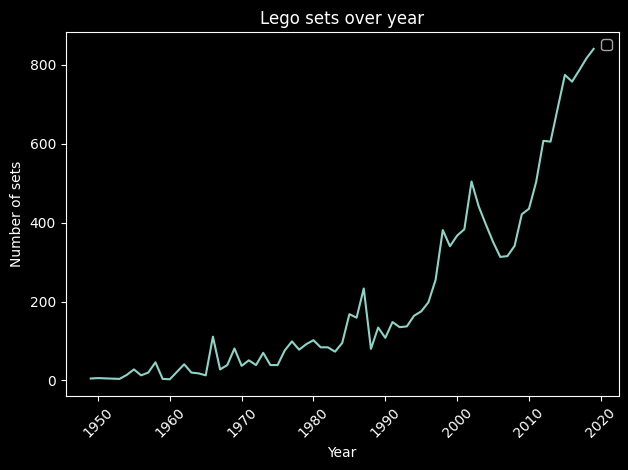

In [16]:
import matplotlib.pyplot as plt
plt.figure()

# Plots
plt.plot(df_sets_per_full_year.set_num.index, df_sets_per_full_year.set_num.values)

# Labels
plt.xlabel("Year")
plt.ylabel("Number of sets")
plt.title("Lego sets over year")


# Legend
plt.legend()

# Improve date display
plt.xticks(rotation=45)

# Show
plt.tight_layout()
plt.show()

### Aggregate Data with the Python .agg() Function

Let's work out the number of different themes shipped by year. This means we have to count the number of unique theme_ids per calendar year.

In [17]:
df_themes = pd.read_csv("data/themes.csv")

In [18]:
df_themes_per_year = df_sets.groupby("year").agg({"theme_id": pd.Series.nunique})[:-2:]
df_sets_per_year = df_sets.groupby("year").agg({"set_num": pd.Series.nunique})[:-2:]
print(df_themes_per_year.head())
print(df_sets_per_full_year.head())

      theme_id
year          
1949         2
1950         1
1953         2
1954         2
1955         4
      set_num  name  theme_id  num_parts
year                                    
1949        5     5         5          5
1950        6     6         6          6
1953        4     4         4          4
1954       14    14        14         14
1955       28    28        28         28


**Challenge**: Plot the number of themes released by year on a line chart. Only include the full calendar years (i.e., exclude 2020 and 2021). 

C:\Users\pedan\AppData\Local\Temp\ipykernel_14204\3529865981.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


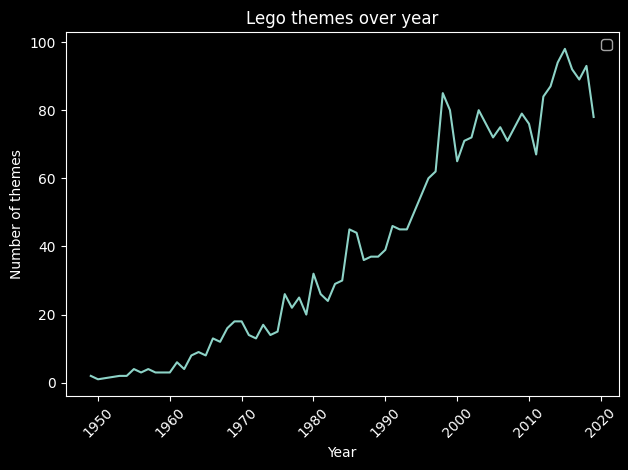

In [19]:
import matplotlib.pyplot as plt
plt.figure()

# Plots
plt.plot(df_themes_per_year.theme_id.index, df_themes_per_year.theme_id.values)

# Labels
plt.xlabel("Year")
plt.ylabel("Number of themes")
plt.title("Lego themes over year")


# Legend
plt.legend()

# Improve date display
plt.xticks(rotation=45)

# Show
plt.tight_layout()
plt.show()

### Line Charts with Two Seperate Axes

In [20]:
print(df_themes_per_year.head())
print(df_sets_per_year.head())



      theme_id
year          
1949         2
1950         1
1953         2
1954         2
1955         4
      set_num
year         
1949        5
1950        6
1953        4
1954       14
1955       28


**Challenge**: Use the <code>.groupby()</code> and <code>.agg()</code> function together to figure out the average number of parts per set. How many parts did the average LEGO set released in 1954 compared to say, 2017?

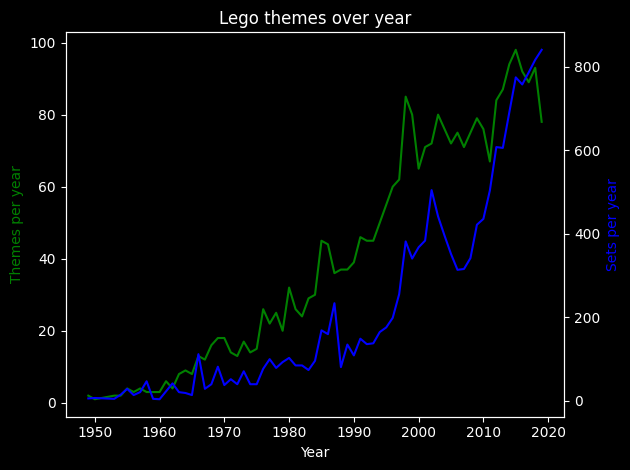

In [21]:
import matplotlib.pyplot as plt
plt.figure()

#Extract the axes
ax1 = plt.gca() # get current axes
ax2 = ax1.twinx() # create another axis sharing the same x1 axes

# Plots
ax1.plot(df_themes_per_year.index, df_themes_per_year.theme_id.values, color="green")

ax2.plot(df_sets_per_year.index, df_sets_per_year.set_num.values, color="blue")

# Labels
ax1.set_xlabel("Year")
ax1.set_ylabel("Themes per year", color="green")
ax2.set_ylabel("Sets per year", color="blue")
plt.title("Lego themes over year")


# Improve date display
plt.xticks(rotation=45)

# Show
plt.tight_layout()
plt.show()

### Scatter Plots in Matplotlib

**Challenge**: Has the size and complexity of LEGO sets increased over time based on the number of parts? Plot the average number of parts over time using a Matplotlib scatter plot. See if you can use the [scatter plot documentation](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.scatter.html) before I show you the solution. Do you spot a trend in the chart?

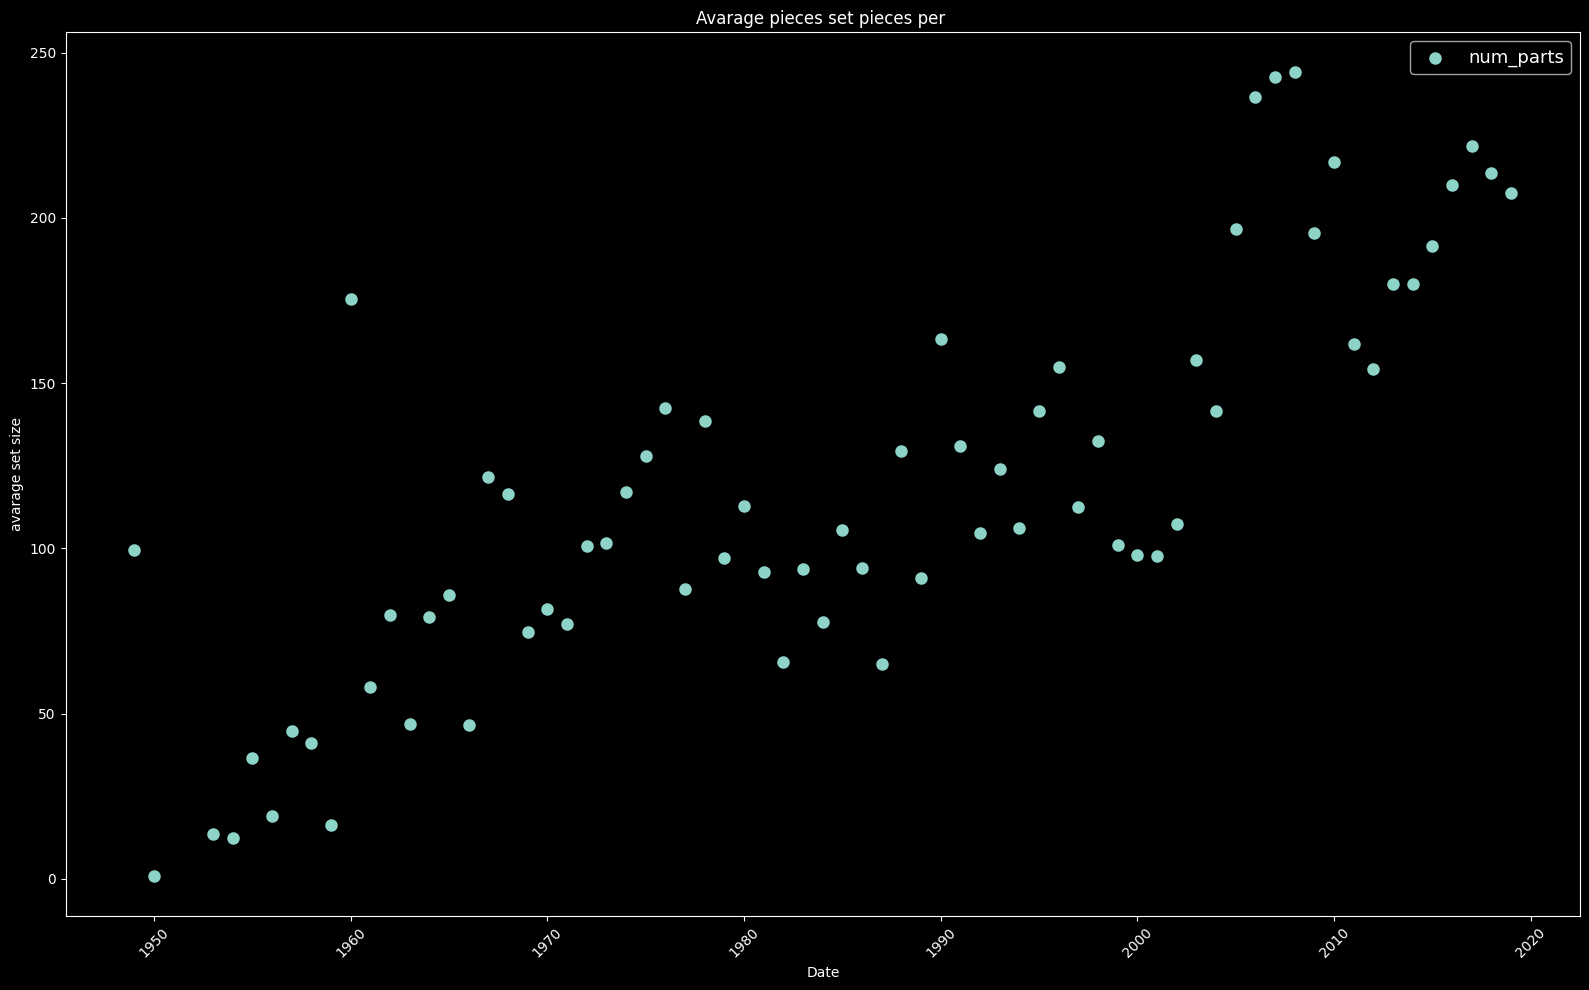

In [22]:
df_sets_mean_per_year=df_sets.groupby("year").agg({"num_parts" : pd.Series.mean})[:-2:]
plt.figure(figsize=(16,10))

# Plots
for column in df_sets_mean_per_year.columns:
  plt.scatter(df_sets_mean_per_year.index, df_sets_mean_per_year[column].values, label=df_sets_mean_per_year[column].name, linewidth=3)

# Labels
plt.xlabel("Date")
plt.ylabel("avarage set size")
plt.title("Avarage pieces set pieces per ")


# Legend
plt.legend(fontsize=13)

# Improve date display
plt.xticks(rotation=45)

# Show
plt.tight_layout()
plt.show()

### Number of Sets per LEGO Theme

LEGO has licensed many hit franchises from Harry Potter to Marvel Super Heros to many others. But which theme has the largest number of individual sets? 

In [23]:
df_sets["theme_id"].value_counts()[::5]

theme_id
158    753
505    328
443    197
453    142
52     115
      ... 
380      1
25       1
34       1
509      1
414      1
Name: count, Length: 115, dtype: int64

**Challenge** Use what you know about HTML markup and tags to display the database schema: https://i.imgur.com/Sg4lcjx.png

<img src="assets/rebrickable_schema.png">


### Database Schemas, Foreign Keys and Merging DataFrames

The themes.csv file has the actual theme names. The sets .csv has <code>theme_ids</code> which link to the <code>id</code> column in the themes.csv. 

**Challenge**: Explore the themes.csv. How is it structured? Search for the name 'Star Wars'. How many <code>id</code>s correspond to this name in the themes.csv? Now use these <code>id</code>s and find the corresponding the sets in the sets.csv (Hint: you'll need to look for matches in the <code>theme_id</code> column)

In [24]:
df_themes = pd.read_csv("data/themes.csv")
theme_count_series = df_sets["theme_id"].value_counts()[::5]
df_theme_count = pd.DataFrame({"id": theme_count_series.index, "set_count": theme_count_series.values})
print(df_theme_count.head())



    id  set_count
0  158        753
1  505        328
2  443        197
3  453        142
4   52        115


In [25]:
merged_df = pd.merge(df_theme_count, df_themes, on='id')

In [26]:
print(df_themes.head())
print(merged_df.head())

   id            name  parent_id
0   1         Technic        NaN
1   2  Arctic Technic        1.0
2   3     Competition        1.0
3   4  Expert Builder        1.0
4   5           Model        1.0
    id  set_count           name  parent_id
0  158        753      Star Wars        NaN
1  505        328      Basic Set      504.0
2  443        197  Service Packs        NaN
3  453        142        Technic      443.0
4   52        115           City       50.0


<BarContainer object of 10 artists>

<Figure size 640x480 with 0 Axes>

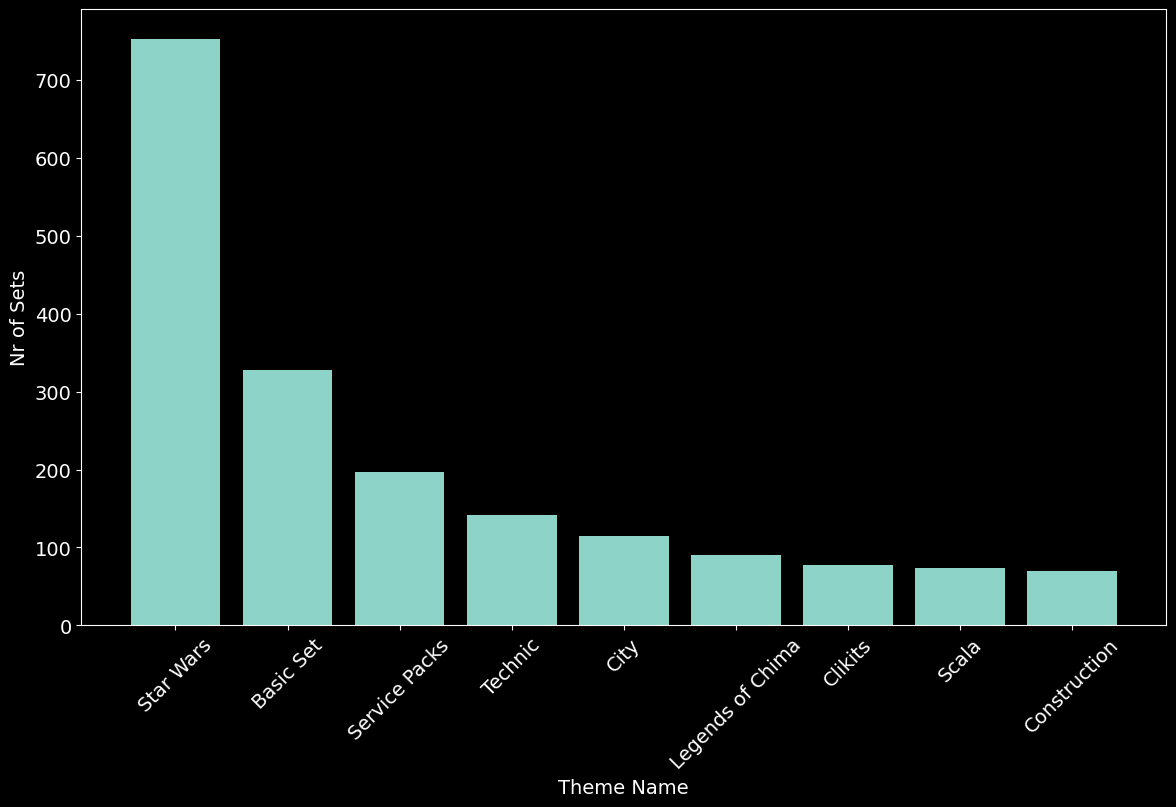

In [27]:
import matplotlib.pyplot as plt
plt.figure()
plt.figure(figsize=(14,8))
#rotates the x names
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.ylabel('Nr of Sets', fontsize=14)
plt.xlabel('Theme Name', fontsize=14)
plt.bar(merged_df.name[:10], merged_df.set_count[:10])


### Merging (i.e., Combining) DataFrames based on a Key
